# Jupyter notebook for running RIME-X

### Required functions and modules

##### Import required modules

In [16]:
import os, sys, re
sys.path.append('../../packages/rimeX/') # location of rimeX package
#---- import quantilemap function from RIME-X package

from rimeX.preproc.quantilemaps import make_quantilemap_prediction


In [17]:
import requests
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import random as random
#import pyam
import numpy as np
from matplotlib.ticker import MultipleLocator
%matplotlib inline


##### Function to download indicator data

In [18]:
def download_indicator_data(indicator, country, subregion=None, season=None, aggregation_spatial=None):

    """
    - season: ['annual', 'MAM', 'JJA', 'SON', 'DJF'] - not all options are available for all
        indicators, please check indicator meta data for availability
    - aggregation: ['area', 'pop', 'gdp'] - not all options are available for all indicators,
        please check indicator meta data for availability
    """

    region = country if not subregion else subregion
    seas = 'annual' if not season else season
    agg = 'area' if not aggregation_spatial else aggregation_spatial

    url = f'https://cie-api-v2.climateanalytics.org/api/timeseries-preprocessed-data/?iso={country}&region={region}&var={indicator}&season={seas}&aggregation_spatial={agg}&format=json'
    
    print(url)

    r = requests.get(url, 
                     headers={'Accept': 'application/json'})
    return xr.DataArray.from_dict(r.json())

##### Function to load scenario data

In [19]:
def load_scenario_data(path, mode='MAGICC', years=''):

    if mode == 'MAGICC':        

        try:
            raw_data = pd.read_csv(path)
        except FileNotFoundError:
            raise FileNotFoundError(f"Could not find the file at: '{path}'. "
                                    f"Please check that the path is correct.")
        
        data = raw_data.iloc[:, np.r_[3, 7:len(raw_data.columns)]]
        data = data.set_index('run_id').transpose().rename_axis('time')

        if years:
            if all(isinstance(x, int) for x in years):
                data = data.loc[str(years[0]):str(years[1])]
            else:
                print('Wrong data type for start and end year, please use integer.')
        
        return data

    elif mode == 'FaIR':

        try:
            raw_data = pd.read_csv(path, index_col='time')
        except FileNotFoundError:
            raise FileNotFoundError(f"Could not find the file at: '{path}'. "
                                    f"Please check that the path is correct.")        
        return raw_data

    else:
        print('Invalid mode selected. Please choose from either MAGICC or FaIR')

### Set required parameters and load metadata (to explore available regions, indicators, etc.)

##### Set parameters for RIME-X and data download

In [20]:
#----- set parameters for pre-processed indicator download
headers = {'Accept': 'application/json'}

#---- set RIME-X parameters

# quantiles to compute, if None all members are returned
# default: [0.5, 0.05, 0.95]
quantiles = [.5, 0.05, 0.1, 0.25, 0.75, 0.9, 0.95] 

# number of samples to draw
# default: 100
samples = 5000

# if True, clip the GMT data to the range of the quantile map, otherwise fill with NaNs
# default: False
clip = True

##### Load meta data with available regions and indicators

In [21]:
#---- request information from the Climate Impact Explorer
r = requests.get('https://cie-api-v2.climateanalytics.org/api/meta/', headers=headers)
meta = r.json()
# meta

#---- create list with all available country codes (ISO3) and regions
countries_and_regions = [x['id'] for x in meta['countries']]
countries_and_regions = {x['id']: x['name'] for x in meta['countries']}
countries_and_regions

{'ABW': 'Aruba',
 'AFG': 'Afghanistan',
 'AGO': 'Angola',
 'AIA': 'Anguilla',
 'ALB': 'Albania',
 'AND': 'Andorra',
 'ARE': 'United Arab Emirates',
 'ARG': 'Argentina',
 'ARM': 'Armenia',
 'ASM': 'American Samoa',
 'ATA': 'Antarctica',
 'ATF': 'French Southern Territories',
 'ATG': 'Antigua and Barbuda',
 'AUS': 'Australia',
 'AUT': 'Austria',
 'AZE': 'Azerbaijan',
 'BDI': 'Burundi',
 'BEL': 'Belgium',
 'BEN': 'Benin',
 'BFA': 'Burkina Faso',
 'BGD': 'Bangladesh',
 'BGR': 'Bulgaria',
 'BHR': 'Bahrain',
 'BHS': 'Bahamas',
 'BIH': 'Bosnia and Herzegovina',
 'BLM': 'Saint Barthélemy',
 'BLR': 'Belarus',
 'BLZ': 'Belize',
 'BMU': 'Bermuda',
 'BOL': 'Bolivia, Plurinational State of',
 'BRA': 'Brazil',
 'BRB': 'Barbados',
 'BRN': 'Brunei Darussalam',
 'BTN': 'Bhutan',
 'BWA': 'Botswana',
 'CAF': 'Central African Republic',
 'CAN': 'Canada',
 'CHE': 'Switzerland',
 'CHL': 'Chile',
 'CHN': 'China',
 'CIV': "Côte d'Ivoire",
 'CMR': 'Cameroon',
 'COD': 'Congo, The Democratic Republic of the',
 '

In [22]:
#---- create list with subregions for one country
country = 'IND'
r = requests.get(f'https://cie-api-v2.climateanalytics.org/api/geo-shapes/?iso={country}', headers=headers).json()
subregions = r['country']['objects']['data']['geometries'][0]['properties']['subregions']
subregions

{'IN.AN': 'Andaman and Nicobar',
 'IN.AP': 'Andra Pradesh',
 'IN.AR': 'Arunachal Pradesh',
 'IN.AS': 'Assam',
 'IN.BR': 'Bihar',
 'IN.CH': 'Chandigarh',
 'IN.CT': 'Chhattisgarh',
 'IN.DN': 'Dadra and Nagar Haveli',
 'IN.DD': 'Daman and Diu',
 'IN.GA': 'Goa',
 'IN.GJ': 'Gujarat',
 'IN.HR': 'Haryana',
 'IN.HP': 'Himachal Pradesh',
 'IN.JK': 'Jammu and Kashmir',
 'IN.JH': 'Jharkhand',
 'IN.KA': 'Karnataka',
 'IN.KL': 'Kerala',
 'IN.LD': 'Lakshadweep',
 'IN.MP': 'Madhya Pradesh',
 'IN.MH': 'Maharashtra',
 'IN.MN': 'Manipur',
 'IN.ML': 'Meghalaya',
 'IN.MZ': 'Mizoram',
 'IN.NL': 'Nagaland',
 'IN.DL': 'NCT of Delhi',
 'IN.OR': 'Odisha',
 'IN.PY': 'Puducherry',
 'IN.PB': 'Punjab',
 'IN.RJ': 'Rajasthan',
 'IN.SK': 'Sikkim',
 'IN.TN': 'Tamil Nadu',
 'IN.TG': 'Telangana',
 'IN.TR': 'Tripura',
 'IN.UP': 'Uttar Pradesh',
 'IN.UT': 'Uttarakhand',
 'IN.WB': 'West Bengal'}

In [23]:
#---- create list with all available indicators
all_indicators = [x['id'] for x in meta['vars']]
all_indicators

['hursAdjust',
 'hussAdjust',
 'prAdjust',
 'prsnAdjust',
 'psAdjust',
 'rldsAdjust',
 'sfcWindAdjust',
 'tasAdjust',
 'tasmaxAdjust',
 'tasminAdjust',
 'qs',
 'dis',
 'maize_yield',
 'rice_yield',
 'soy_yield',
 'wheat_yield',
 'labour-productivity-loss',
 'rx5day',
 'daily_temperature_variability',
 'extreme_daily_rainfall',
 'number_of_wet_days',
 'total_annual_precipitation',
 'drought_intensity',
 'consecutive_dry_days',
 'consecutive_tropical_nights',
 'cooling_degree_days',
 'fwils',
 'fwixd',
 'heavy_precipitation_days',
 'rx1day',
 'spei_gamma_12',
 'spei_gamma_12_min',
 'TXx',
 'wet_bulb_temperature',
 'wsi',
 'moderate_drought',
 'severe_drought',
 'extreme_drought',
 'superextreme_drought',
 'HI-caution',
 'HI-extreme-caution',
 'HI-danger',
 'HI-extreme-danger']

In [24]:
#---- more information for an indicator can be pulled using the following lines
#---- index is the position of the desired indicator in the indicators variable list
all_indicator_info = meta['vars'][39]
all_indicator_info
# print(all_indicator_info)
# print(all_indicator_info['description'])
# print(all_indicator_info['name'])
# print(all_indicator_info['unit'])
# print(all_indicator_info['change_type'])

{'change_type': None,
 'description': 'Number of days per year at which the daily maximum Heat Index exceeds the ‘caution’ threshold of 26.7 °C. The Heat Index, is based on a definition by NOAA and relies on daily maximum temperature (tasmax) and relative humidity (hurs), and is widely used for heat risk warnings.',
 'disclaimer': 'Daily maximum HI values require relative humidity values during the hottest hour of the day - which are not available in ISIMIP3 model environment. To account for this we employ a physics based approximation, which makes use of relationships between daily mean temperature, saturation vapor pressure, daily mean vapor pressure and specific humidity. To adjust remaining model biases, a grid-point wise quantile mapping was applied to HI projections using distributions from historical ISIMIP3 simulations and ERA5 reanalysis data for the period 1980-2010. This standard approach adjusts simulated HI data to fit the distribution of observed HI values. While this app

### Generate emulations for one scenario, one indicator

##### Load scenario data

In [25]:
#---- set input type of and path to scenario data
input_type = 'MAGICC' # choose either MAGICC or FaIR'
#path = '/Users/quentinlejeune/Documents/VUB/Lifetime_Exposure/Tutorials-RIME-X/example_data/h_cpol_REMIND-MAgPIE-3.3-4.7_MAGICC_out.csv'
path = os.path.join('../data/rimex-data/example_data/h_cpol_REMIND-MAgPIE-3.3-4.7_MAGICC_out.csv'
)

#---- set start and end year for plotting data
years = [1950, 2120]
tick_interval = 20 # set interval for x axis tick for plotting

#---- load scenario data
scenario_data = load_scenario_data(path, input_type, years) # choose either 'MAGICC' or 'FaIR' 
scenario_data

run_id,0,1,2,3,4,5,6,7,8,9,...,590,591,592,593,594,595,596,597,598,599
time,,,,,,,,,,,,,,,,,,,,,
1950,0.292585,0.438662,0.340998,0.257862,0.329837,0.248987,0.241079,0.301997,0.200866,0.311245,...,0.294072,0.255257,0.283785,0.318627,0.351754,0.257679,0.334874,0.338989,0.261699,0.274178
1951,0.288047,0.430929,0.338046,0.250158,0.325014,0.241929,0.239854,0.294336,0.195313,0.306684,...,0.288972,0.252570,0.276622,0.311472,0.344087,0.253745,0.322209,0.337214,0.252343,0.269774
1952,0.283380,0.423453,0.334399,0.244053,0.318764,0.236729,0.238596,0.287516,0.190495,0.302089,...,0.283431,0.249150,0.271003,0.305825,0.336572,0.250071,0.309692,0.333583,0.245890,0.265996
1953,0.280973,0.418934,0.331970,0.240216,0.315587,0.235026,0.238219,0.282486,0.188505,0.298684,...,0.279975,0.248346,0.268370,0.303839,0.331237,0.248963,0.299381,0.330912,0.242011,0.263912
1954,0.280057,0.415458,0.331293,0.238834,0.313681,0.236406,0.239379,0.279640,0.187510,0.297351,...,0.278570,0.248900,0.267816,0.304400,0.327749,0.248806,0.291617,0.329837,0.241009,0.263721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2096,3.046854,5.134120,3.309005,2.536957,3.096927,1.977715,2.422237,3.845591,2.706767,2.951889,...,3.390872,2.176961,2.610046,2.928317,4.119990,2.725258,4.607058,3.409866,2.730762,2.945229
2097,3.057978,5.165702,3.321788,2.540989,3.106123,1.982281,2.430273,3.865217,2.719263,2.960890,...,3.403436,2.182101,2.613687,2.939712,4.137230,2.734228,4.631598,3.425117,2.737015,2.957877
2098,3.069319,5.197252,3.334961,2.546047,3.115836,1.987513,2.438394,3.885475,2.731837,2.970669,...,3.416470,2.187532,2.618132,2.951541,4.154943,2.743455,4.656442,3.440516,2.744483,2.970758


##### Select country & indicator and download indicator data from the Climate Impact Explorer

In [26]:
#---- set parameters
country = 'IND'
indicator = 'extreme_drought'

#---- download required indicator data
indicator_data = download_indicator_data(indicator, country, aggregation_spatial='pop')
indicator_data

https://cie-api-v2.climateanalytics.org/api/timeseries-preprocessed-data/?iso=IND&region=IND&var=extreme_drought&season=annual&aggregation_spatial=pop&format=json


<xarray.DataArray 'extreme_drought' (warming_level: 47, quantile: 101)>
array([[ 1.72336445,  1.72336445,  1.73209825, ..., 25.661537  ,
        26.11287334, 26.21702788],
       [ 1.97716271,  1.97716271,  2.0403235 , ..., 27.10158509,
        27.85063318, 27.97547453],
       [ 2.59822545,  2.59822545,  2.61549702, ..., 28.02114656,
        28.51263616, 28.62605684],
       ...,
       [82.72296338, 82.72296338, 82.72296338, ..., 83.83214744,
        83.83214744, 83.83214744],
       [84.29629622, 84.29629622, 84.29629622, ..., 84.29629622,
        84.29629622, 84.29629622],
       [84.69721398, 84.69721398, 84.69721398, ..., 84.69721398,
        84.69721398, 84.69721398]])
Coordinates:
  * quantile       (quantile) float64 0.0 0.01 0.02 0.03 ... 0.97 0.98 0.99 1.0
    region         <U3 'IND'
  * warming_level  (warming_level) float64 1.0 1.1 1.2 1.3 ... 5.3 5.4 5.5 5.6

##### Run RIME-X

In [27]:
#---- run RIME-X
rimex_data = make_quantilemap_prediction(indicator_data, scenario_data, quantiles=quantiles, samples=samples, clip=clip)
rimex_data

<xarray.DataArray (quantile: 7, year: 151)>
array([[10.60870628, 10.60870628, 10.60870628, ..., 51.78488562,
        52.20762338, 52.59215315],
       [ 1.75892151,  1.75892151,  1.75892151, ..., 25.87960118,
        26.0501689 , 26.32861562],
       [ 2.24765473,  2.24765473,  2.24765473, ..., 29.15590061,
        29.21379711, 29.2997382 ],
       ...,
       [16.23921212, 16.23921212, 16.23921212, ..., 71.42654392,
        71.7012335 , 72.19106627],
       [20.99240816, 20.99240816, 20.99240816, ..., 81.82079724,
        81.84432214, 82.02266536],
       [21.98660371, 21.98660371, 21.98660371, ..., 84.67905954,
        84.7699493 , 84.9604887 ]])
Coordinates:
  * quantile  (quantile) float64 0.5 0.05 0.1 0.25 0.75 0.9 0.95
  * year      (year) object '1950' '1951' '1952' '1953' ... '2098' '2099' '2100'

##### Plot results

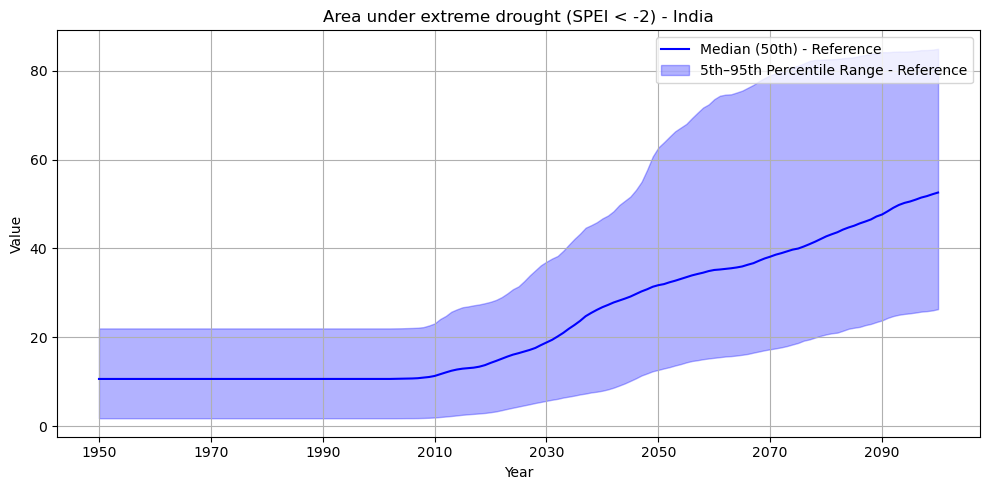

In [28]:
#---- plot results
plt.figure(figsize=(10, 5))
plt.plot(rimex_data.sel(quantile=0.5)['year'], rimex_data.sel(quantile=0.5), label='Median (50th) - Reference', color='blue')
plt.fill_between(rimex_data.sel(quantile=0.5)['year'], rimex_data.sel(quantile=0.05), rimex_data.sel(quantile=0.95), color='blue', 
                 alpha=0.3, label='5th–95th Percentile Range - Reference')

plt.xlabel('Year')
plt.ylabel(f'Value')
plt.gca().xaxis.set_major_locator(MultipleLocator(tick_interval))
plt.title(f'{meta["vars"][all_indicators.index(indicator)]["name"]} - {countries_and_regions[country]}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Generate emulations for two scenarios, two indicators, one country

https://cie-api-v2.climateanalytics.org/api/timeseries-preprocessed-data/?iso=IND&region=IND&var=extreme_drought&season=annual&aggregation_spatial=pop&format=json
https://cie-api-v2.climateanalytics.org/api/timeseries-preprocessed-data/?iso=IND&region=IND&var=HI-danger&season=annual&aggregation_spatial=pop&format=json


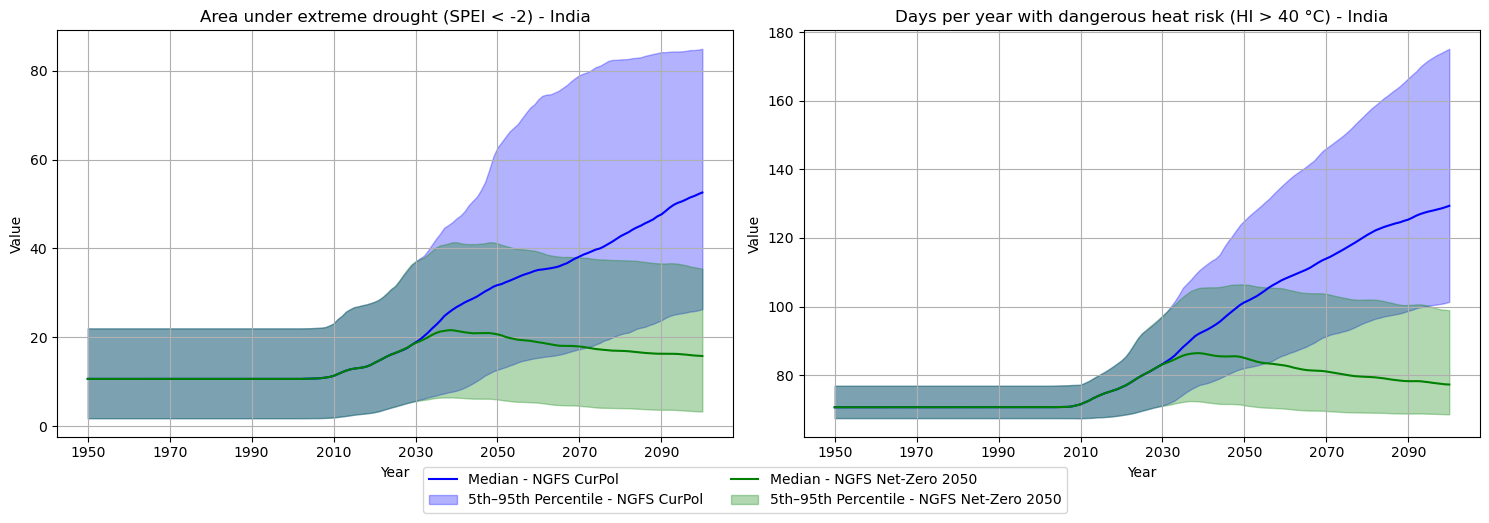

In [29]:
#---- define parameters

path_warming_data = os.path.join('../data/rimex-data/example_data/')

country = 'IND'
indicators = ['extreme_drought', 'HI-danger']
scenarios = {'NGFS CurPol': os.path.join(path_warming_data,'h_cpol_REMIND-MAgPIE-3.3-4.7_MAGICC_out.csv'), 
             'NGFS Net-Zero 2050': os.path.join(path_warming_data,'o_1p5c_REMIND-MAgPIE-3.3-4.7_MAGICC_out.csv')}
input_type = 'MAGICC'
years = [1950, 2100]
colors = ['blue', 'green']
tick_interval = 20

#---- load scenario data
scenario_data = [load_scenario_data(scenarios[scen], input_type, years) for scen in scenarios]

#---- download data, run RIME-X and plot results
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
axs = axs.flatten()

for ind_index, ind in enumerate(indicators):

    #---- download indicator data
    indicator_data = download_indicator_data(ind, country, aggregation_spatial='pop')

    #---- run RIME-X for all scenarios
    for scen_index, scen in enumerate(scenarios):

        #---- plot results
        rimex_data = make_quantilemap_prediction(indicator_data, scenario_data[scen_index], quantiles=quantiles, samples=samples, clip=clip)
        axs[ind_index].plot(rimex_data.sel(quantile=0.5)['year'], rimex_data.sel(quantile=0.5), label=f'Median - {scen}', color=colors[scen_index])
        axs[ind_index].fill_between(rimex_data.sel(quantile=0.5)['year'], rimex_data.sel(quantile=0.05), rimex_data.sel(quantile=0.95), 
                         color=colors[scen_index], alpha=0.3, label=f'5th–95th Percentile - {scen}')

     #---- set labels, titles and grid
    axs[ind_index].set_xlabel('Year')
    axs[ind_index].set_ylabel('Value')
    axs[ind_index].set_title(f'{meta["vars"][all_indicators.index(ind)]["name"]} - {countries_and_regions[country]}')
    axs[ind_index].grid(True)
    axs[ind_index].xaxis.set_major_locator(MultipleLocator(tick_interval))

handles, labels = axs[ind_index].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

### Generate emulations for two scenarios and two indicators, several countries

{'country': {'type': 'Topology', 'objects': {'data': {'geometries': [{'properties': {'adm0_a3': 'PRT', 'initial_bounds': [[-31.25, 42.25], [-6.25, 30.25]], 'subregions': {'PRT.1_1': 'Aveiro', 'PRT.2_1': 'Azores', 'PRT.3_1': 'Beja', 'PRT.4_1': 'Braga', 'PRT.5_1': 'Bragança', 'PRT.6_1': 'Castelo Branco', 'PRT.7_1': 'Coimbra', 'PRT.8_1': 'Évora', 'PRT.9_1': 'Faro', 'PRT.10_1': 'Guarda', 'PRT.11_1': 'Leiria', 'PRT.12_1': 'Lisboa', 'PRT.13_1': 'Madeira', 'PRT.14_1': 'Portalegre', 'PRT.15_1': 'Porto', 'PRT.16_1': 'Santarém', 'PRT.17_1': 'Setúbal', 'PRT.18_1': 'Viana do Castelo', 'PRT.19_1': 'Vila Real', 'PRT.20_1': 'Viseu'}}, 'type': 'MultiPolygon', 'arcs': [[[0]], [[1]], [[2]], [[3]], [[4]], [[5]], [[6]], [[7]], [[8]]]}], 'type': 'GeometryCollection'}}, 'bbox': [-31.282958984375, 32.648291015625034, -6.212499999999949, 42.13740234375001], 'arcs': [[[-17.190869140624926, 32.86860351562498], [-17.054492187499932, 32.81586914062498], [-16.92919921875, 32.841406250000034], [-16.77397460937499, 

ValueError: cannot convert dict without the key 'data''

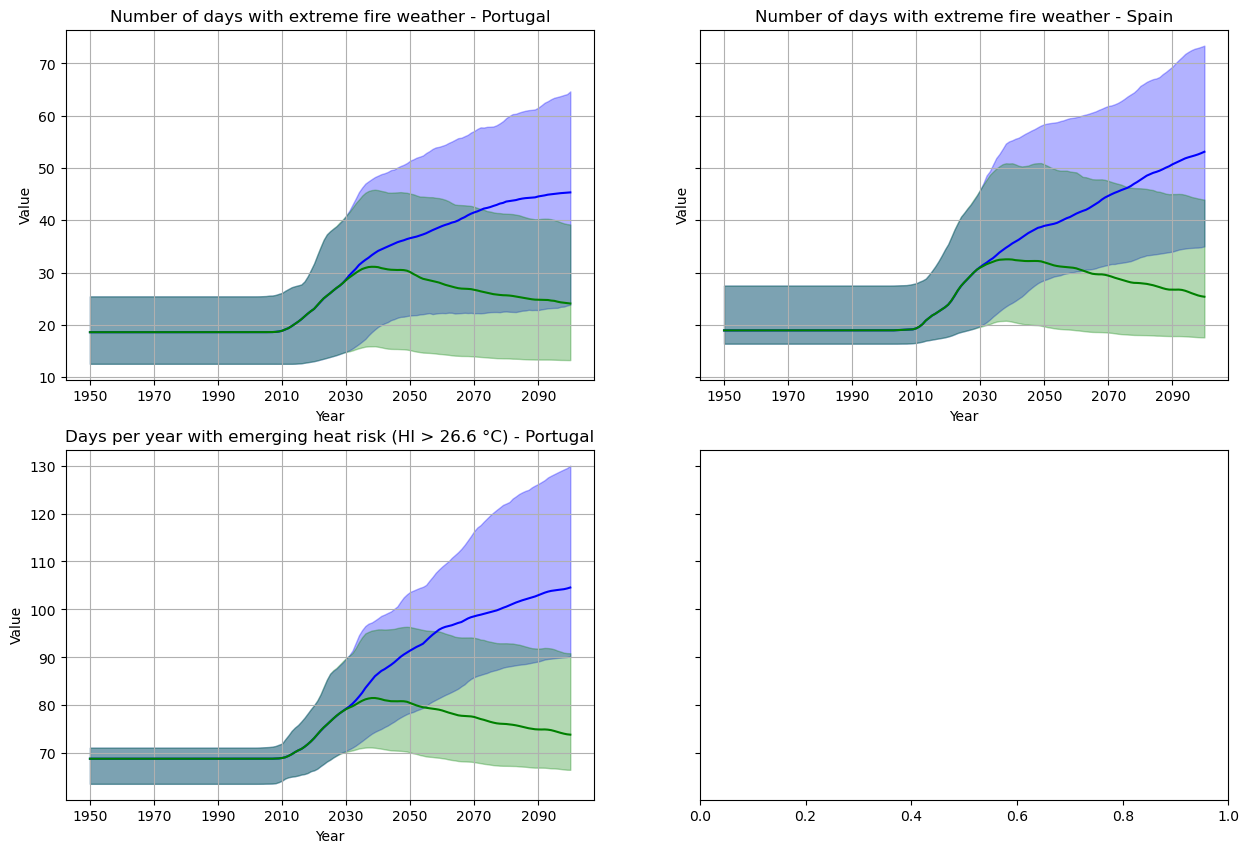

In [30]:
#---- define parameter
countries = ['PRT', 'ESP']
indicators = ['fwixd', 'HI-caution']
scenarios = {'NGFS CurPol': os.path.join(path_warming_data,'h_cpol_REMIND-MAgPIE-3.3-4.7_MAGICC_out.csv'), 
             'NGFS Net-Zero 2050': os.path.join(path_warming_data,'o_1p5c_REMIND-MAgPIE-3.3-4.7_MAGICC_out.csv')}
input_type = 'MAGICC'
years = [1950, 2100]
colors = ['blue', 'green']
tick_interval = 20

#---- load scenario data
scenario_data = [load_scenario_data(scenarios[scen], input_type, years) for scen in scenarios]

#---- download data, run RIME-X and plot results
fig, axs = plt.subplots(nrows=len(indicators), ncols=len(countries), figsize=(15, 10), sharey='row')

for country_index, country in enumerate(countries):

    #---- load list with subregions for country
    r = requests.get(f'https://cie-api-staging.climateanalytics.org/api/geo-shapes/?iso={country}', headers=headers).json()
    print(r)
    #subregions = r['country']['objects']['data']['geometries'][0]['properties']['subregions']

    for ind_index, ind in enumerate(indicators):        

        print(ind, country)

        #---- download indicator data
        ind_data = download_indicator_data(ind, country, aggregation_spatial='pop')

        #---- run RIME-X for all scenarios
        for scen_index, scen in enumerate(scenarios):

            rimex_data = make_quantilemap_prediction(ind_data, scenario_data[scen_index], quantiles=quantiles, samples=samples, clip=clip)
            axs[ind_index, country_index].plot(rimex_data.sel(quantile=0.5)['year'], rimex_data.sel(quantile=0.5), label=f'Median - {scen}', color=colors[scen_index])
            axs[ind_index, country_index].fill_between(rimex_data.sel(quantile=0.5)['year'], rimex_data.sel(quantile=0.05), rimex_data.sel(quantile=0.95), 
                         color=colors[scen_index], alpha=0.3, label=f'5th–95th Percentile - {scen}')
        
        #---- set labels, titles and grid
        axs[ind_index, country_index].set_xlabel('Year')
        axs[ind_index, country_index].set_ylabel('Value')
        axs[ind_index, country_index].set_title(f'{meta["vars"][all_indicators.index(ind)]["name"]} - {countries_and_regions[country]}') 
        axs[ind_index, country_index].grid(True)
        axs[ind_index, country_index].xaxis.set_major_locator(MultipleLocator(tick_interval))


handles, labels = axs[ind_index, country_index].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

### Save data - several indicators, one country, several scenarios

In [ ]:
#---- specify country, indicators, scenarios, aggregation method
country = 'IND'
indicators = ['extreme_drought', 'HI-danger', 'heavy_precipitation_days', 'fwixd']

scenarios = {'NGFS CurPol': os.path.join(path_warming_data,'h_cpol_REMIND-MAgPIE-3.3-4.7_MAGICC_out.csv'), 
             'NGFS Net-Zero 2050': os.path.join(path_warming_data,'o_1p5c_REMIND-MAgPIE-3.3-4.7_MAGICC_out.csv')}

agg_method = 'pop'

#---- load scenario data
scenario_data = [load_scenario_data(scenarios[scen], 'MAGICC', years) for scen in scenarios]

all_data = xr.Dataset()

#---- loop over all selected countries
for indicator in indicators:

    #---- download indicator data
    indicator_data = download_indicator_data(indicator, country, aggregation_spatial=agg_method)

    #---- run RIME-X for all scenarios
    for scen_index, scen in enumerate(scenarios):
        
        rimex_data = make_quantilemap_prediction(indicator_data, scenario_data[scen_index], quantiles=quantiles, samples=samples, clip=clip)
        all_data[indicator, scen] = rimex_data

all_data

https://cie-api-v2.climateanalytics.org/api/timeseries-preprocessed-data/?iso=IND&region=IND&var=extreme_drought&season=annual&aggregation_spatial=pop&format=json
https://cie-api-v2.climateanalytics.org/api/timeseries-preprocessed-data/?iso=IND&region=IND&var=HI-danger&season=annual&aggregation_spatial=pop&format=json
https://cie-api-v2.climateanalytics.org/api/timeseries-preprocessed-data/?iso=IND&region=IND&var=heavy_precipitation_days&season=annual&aggregation_spatial=pop&format=json
https://cie-api-v2.climateanalytics.org/api/timeseries-preprocessed-data/?iso=IND&region=IND&var=fwixd&season=annual&aggregation_spatial=pop&format=json


<xarray.Dataset>
Dimensions:                                             (quantile: 7, year: 151)
Coordinates:
  * quantile                                            (quantile) float64 0....
  * year                                                (year) object '1950' ...
Data variables:
    ('extreme_drought', 'NGFS CurPol')                  (quantile, year) float64 ...
    ('extreme_drought', 'NGFS Net-Zero 2050')           (quantile, year) float64 ...
    ('HI-danger', 'NGFS CurPol')                        (quantile, year) float64 ...
    ('HI-danger', 'NGFS Net-Zero 2050')                 (quantile, year) float64 ...
    ('heavy_precipitation_days', 'NGFS CurPol')         (quantile, year) float64 ...
    ('heavy_precipitation_days', 'NGFS Net-Zero 2050')  (quantile, year) float64 ...
    ('fwixd', 'NGFS CurPol')                            (quantile, year) float64 ...
    ('fwixd', 'NGFS Net-Zero 2050')                     (quantile, year) float64 ...

##### Convert xarray dataset to dataframe and adjust format

In [ ]:
#---- convert to dataframe
all_data_df = all_data.to_dataframe().reset_index()
all_data_df 

quantile  year extreme_drought                      HI-danger  \
                        NGFS CurPol NGFS Net-Zero 2050 NGFS CurPol   
0        0.50  1950       10.608706          10.608706   70.653938   
1        0.50  1951       10.608706          10.608706   70.653938   
2        0.50  1952       10.608706          10.608706   70.653938   
3        0.50  1953       10.608706          10.608706   70.653938   
4        0.50  1954       10.608706          10.608706   70.653938   
...       ...   ...             ...                ...         ...   
1052     0.95  2096       84.485519          36.212166  172.573788   
1053     0.95  2097       84.660423          35.945714  173.327670   
1054     0.95  2098       84.679060          35.770387  173.881110   
1055     0.95  2099       84.769949          35.592127  174.528995   
1056     0.95  2100       84.960489          35.450302  175.131518   

                        heavy_precipitation_days                     \
     NGFS Net-Zero 2050              NGFS CurPol NGFS Net-Zero 2050   
0             70.653938                34.707411          34.707411   
1             70.653938                34.707411          34.707411   
2             70.653938                34.707411          34.707411   
3             70.653938                34.707411          34.707411   
4             70.653938                34.707411          34.707411   
...                 ...                      ...                ...   
1052          99.823530                45.111275          40.826048   
1053          99.456605                45.117547          40.803824   
1054          99.153531                45.101190          40.767275   
1055          99.057824                45.117162          40.758749   
1056          98.950206                45.146550          40.753374   

           fwixd                     
     NGFS CurPol NGFS Net-Zero 2050  
0      16.619823          16.619823  
1      16.619823          16.619823  
2      16.619823          16.619823  
3      16.619823          16.619823  
4      16.619823          16.619823  
...          ...                ...  
1052   29.924226          22.258903  
1053   30.453324          22.182676  
1054   30.908150          22.120718  
1055   31.284909          22.078296  
1056   31.414710          22.041445  

[1057 rows x 10 columns]

##### Save to csv : dont do this anymore

In [ ]:
#---- save to csv
scen_names = [scen_name.replace(' ', '-') for scen_name in scenarios.keys()]
scen_names_stitched = '_'.join(scen_names)
ind_stitched = '_'.join(indicators)
path_csvfile = f'{scen_names_stitched}_{ind_stitched}_{country}_{agg_method}.csv'
all_data_df.to_csv(path_csvfile, index=False)
path_csvfile

'NGFS-CurPol_NGFS-Net-Zero-2050_extreme_drought_HI-danger_heavy_precipitation_days_fwixd_IND_pop.csv'

In [ ]:
print(all_data_df.columns)

MultiIndex([(                'quantile',                   ''),
            (                    'year',                   ''),
            (         'extreme_drought',        'NGFS CurPol'),
            (         'extreme_drought', 'NGFS Net-Zero 2050'),
            (               'HI-danger',        'NGFS CurPol'),
            (               'HI-danger', 'NGFS Net-Zero 2050'),
            ('heavy_precipitation_days',        'NGFS CurPol'),
            ('heavy_precipitation_days', 'NGFS Net-Zero 2050'),
            (                   'fwixd',        'NGFS CurPol'),
            (                   'fwixd', 'NGFS Net-Zero 2050')],
           )


In [ ]:
#---- save to pickle
#all_data_df.to_pickle('CurPol_NZ2050_fwixd_HI-caution_PRT_pop.pkl')

### Save data - several indicators, one state, several scenarios

In [ ]:
#---- specify country, province/state, indicators, scenarios
country = 'IND'
state = 'IN.KL'

indicators = ['extreme_drought', 'HI-danger', 'heavy_precipitation_days', 'fwixd']

scenarios = {'NGFS CurPol': '/Users/quentinlejeune/Documents/VUB/Lifetime_Exposure/Tutorials-RIME-X/example_data/h_cpol_REMIND-MAgPIE-3.3-4.7_MAGICC_out.csv', 
             'NGFS Net-Zero 2050': '/Users/quentinlejeune/Documents/VUB/Lifetime_Exposure/Tutorials-RIME-X/example_data/o_1p5c_REMIND-MAgPIE-3.3-4.7_MAGICC_out.csv'}

#---- load scenario data
scenario_data = [load_scenario_data(scenarios[scen], 'MAGICC', years) for scen in scenarios]

all_data = xr.Dataset()

#---- loop over all selected countries
for indicator in indicators:

    #---- download indicator data
    indicator_data = download_indicator_data(indicator, country, state, aggregation_spatial='pop')

    #---- run RIME-X for all scenarios
    for scen_index, scen in enumerate(scenarios):
        
        rimex_data = make_quantilemap_prediction(indicator_data, scenario_data[scen_index], quantiles=quantiles, samples=samples, clip=clip)
        all_data[indicator, scen] = rimex_data

all_data

<xarray.Dataset> Size: 69kB
Dimensions:                                             (quantile: 7, year: 151)
Coordinates:
  * quantile                                            (quantile) float64 56B ...
  * year                                                (year) object 1kB '19...
Data variables:
    ('extreme_drought', 'NGFS CurPol')                  (quantile, year) float64 8kB ...
    ('extreme_drought', 'NGFS Net-Zero 2050')           (quantile, year) float64 8kB ...
    ('HI-danger', 'NGFS CurPol')                        (quantile, year) float64 8kB ...
    ('HI-danger', 'NGFS Net-Zero 2050')                 (quantile, year) float64 8kB ...
    ('heavy_precipitation_days', 'NGFS CurPol')         (quantile, year) float64 8kB ...
    ('heavy_precipitation_days', 'NGFS Net-Zero 2050')  (quantile, year) float64 8kB ...
    ('fwixd', 'NGFS CurPol')                            (quantile, year) float64 8kB ...
    ('fwixd', 'NGFS Net-Zero 2050')                     (quantile, year) float64 8kB ...

##### Convert xarray dataset to dataframe and adjust format

In [ ]:
#---- convert to dataframe
all_data_df = all_data.to_dataframe().reset_index()
all_data_df 

quantile  year extreme_drought                      HI-danger  \
                        NGFS CurPol NGFS Net-Zero 2050 NGFS CurPol   
0        0.50  1950       18.067234          18.067234    2.939880   
1        0.50  1951       18.067234          18.067234    2.939880   
2        0.50  1952       18.067234          18.067234    2.939880   
3        0.50  1953       18.067234          18.067234    2.939880   
4        0.50  1954       18.067234          18.067234    2.939880   
...       ...   ...             ...                ...         ...   
1052     0.95  2096       61.321116          37.945818   78.734004   
1053     0.95  2097       61.359993          37.857101   79.305419   
1054     0.95  2098       61.484406          37.886257   80.415956   
1055     0.95  2099       61.557912          37.782074   81.589200   
1056     0.95  2100       61.699899          37.752707   82.725297   

                        heavy_precipitation_days                     \
     NGFS Net-Zero 2050              NGFS CurPol NGFS Net-Zero 2050   
0              2.939880                73.174848          73.174848   
1              2.939880                73.174848          73.174848   
2              2.939880                73.174848          73.174848   
3              2.939880                73.174848          73.174848   
4              2.939880                73.174848          73.174848   
...                 ...                      ...                ...   
1052          12.772854                80.214948          77.994980   
1053          12.652162                80.240555          77.993523   
1054          12.558981                80.261446          77.986071   
1055          12.471757                80.242152          77.972969   
1056          12.459042                80.246363          77.972498   

           fwixd                     
     NGFS CurPol NGFS Net-Zero 2050  
0      19.917844          19.917844  
1      19.917844          19.917844  
2      19.917844          19.917844  
3      19.917844          19.917844  
4      19.917844          19.917844  
...          ...                ...  
1052   39.847596          28.650298  
1053   39.942038          28.596078  
1054   40.050828          28.525148  
1055   40.168727          28.467828  
1056   40.259822          28.433266  

[1057 rows x 10 columns]

##### Save to csv

In [ ]:
#---- save to csv
scen_names = [scen_name.replace(' ', '-') for scen_name in scenarios.keys()]
scen_names_stitched = '_'.join(scen_names)
ind_stitched = '_'.join(indicators)
state_tosave = state.replace('.','-')

path_csvfile = f'{scen_names_stitched}_{ind_stitched}_{state_tosave}_{agg_method}.csv'
all_data_df.to_csv(path_csvfile, index=False)
path_csvfile

'NGFS-CurPol_NGFS-Net-Zero-2050_extreme_drought_HI-danger_heavy_precipitation_days_fwixd_IN-KL_pop.csv'